# Lab 9: Support Vector Machine (SVM) and Principal Component Analysis (PCA)


In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer, load_wine
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

sns.set_theme(style='whitegrid', context='notebook')
RANDOM_STATE = 42

## Part A: Support Vector Machine (SVM)

In [2]:
cancer = load_breast_cancer(as_frame=True)
X_cancer = cancer.data.copy()
y_cancer = cancer.target.copy()  # 0 = malignant, 1 = benign

print(f'Dataset shape: {X_cancer.shape}')
print(f'Missing values: {X_cancer.isna().sum().sum()}')
print(f'Duplicate rows: {X_cancer.duplicated().sum()}')
print('\nClass distribution:')
display(y_cancer.value_counts().rename(index=dict(enumerate(cancer.target_names))).to_frame('count'))
display(X_cancer.head())

Dataset shape: (569, 30)
Missing values: 0
Duplicate rows: 0

Class distribution:


,count
target,
benign,357
malignant,212


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


### Train-test split and hyperparameter tuning

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X_cancer, y_cancer, test_size=0.20, random_state=RANDOM_STATE, stratify=y_cancer
)

svm_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='linear'))
])

param_grid = {'svm__C': [0.001, 0.01, 0.1, 1, 10, 100]}
grid_search = GridSearchCV(
    svm_pipeline, param_grid, cv=5, scoring='f1', n_jobs=1, return_train_score=True
)
grid_search.fit(X_train, y_train)

print(f'Training samples: {X_train.shape[0]}')
print(f'Testing samples:  {X_test.shape[0]}')
print(f'Best parameters: {grid_search.best_params_}')
print(f'Best mean CV F1 score: {grid_search.best_score_:.4f}')

Training samples: 455
Testing samples:  114
Best parameters: {'svm__C': 0.1}
Best mean CV F1 score: 0.9828


In [4]:
cv_results = pd.DataFrame(grid_search.cv_results_)
tuning_summary = cv_results[[
    'param_svm__C', 'mean_train_score', 'mean_test_score', 'std_test_score', 'rank_test_score'
]].rename(columns={
    'param_svm__C': 'C', 'mean_train_score': 'Mean Train F1',
    'mean_test_score': 'Mean CV F1', 'std_test_score': 'CV F1 Std',
    'rank_test_score': 'Rank'
}).sort_values('C')
display(tuning_summary.round({'Mean Train F1': 4, 'Mean CV F1': 4, 'CV F1 Std': 4}))

,C,Mean Train F1,Mean CV F1,CV F1 Std,Rank
0,0.001,0.9520,0.9502,0.0132,6
1,0.010,0.9823,0.9795,0.0115,2
2,0.100,0.9882,0.9828,0.0107,1
3,1.000,0.9922,0.9738,0.0110,3
4,10.000,0.9956,0.9718,0.0120,4
5,100.000,0.9991,0.9556,0.0174,5


### Test-set evaluation


In [5]:
best_svm = grid_search.best_estimator_
y_pred = best_svm.predict(X_test)

svm_metrics = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score'],
    'Score': [
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred)
    ]
})
display(svm_metrics.round({'Score': 4}))
print('Classification report:\n')
print(classification_report(y_test, y_pred, target_names=cancer.target_names, digits=4))

,Metric,Score
0,Accuracy,0.9825
1,Precision,0.9861
2,Recall,0.9861
3,F1 Score,0.9861


Classification report:

              precision    recall  f1-score   support

   malignant     0.9762    0.9762    0.9762        42
      benign     0.9861    0.9861    0.9861        72

    accuracy                         0.9825       114
   macro avg     0.9812    0.9812    0.9812       114
weighted avg     0.9825    0.9825    0.9825       114



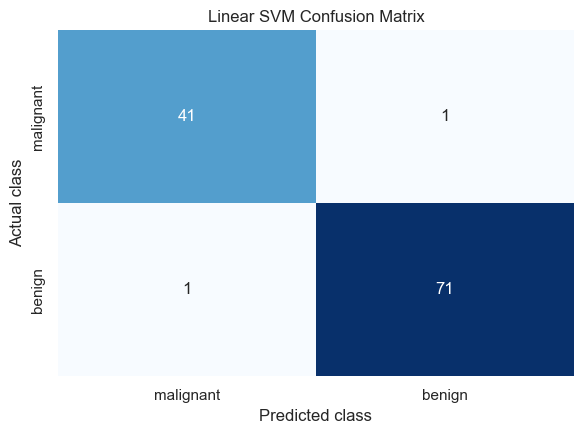

In [6]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4.5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=cancer.target_names, yticklabels=cancer.target_names)
plt.title('Linear SVM Confusion Matrix')
plt.xlabel('Predicted class')
plt.ylabel('Actual class')
plt.tight_layout()
plt.show()

## Part B: Principal Component Analysis (PCA)

The UCI Wine dataset contains 178 samples, 13 continuous chemical-analysis features, and three wine cultivars. PCA is unsupervised: class labels are not used to calculate the components. Features are standardized first because their measurement units and ranges differ.

In [7]:
wine = load_wine(as_frame=True)
X_wine = wine.data.copy()
y_wine = wine.target.copy()

print(f'Dataset shape: {X_wine.shape}')
print(f'Missing values: {X_wine.isna().sum().sum()}')
print('Class counts:', y_wine.value_counts().sort_index().to_dict())
display(X_wine.describe().T[['mean', 'std', 'min', 'max']])

wine_scaler = StandardScaler()
X_wine_scaled = wine_scaler.fit_transform(X_wine)

Dataset shape: (178, 13)
Missing values: 0
Class counts: {0: 59, 1: 71, 2: 48}


,mean,std,min,max
alcohol,13.000618,0.811827,11.03,14.83
malic_acid,2.336348,1.117146,0.74,5.80
ash,2.366517,0.274344,1.36,3.23
alcalinity_of_ash,19.494944,3.339564,10.60,30.00
magnesium,99.741573,14.282484,70.00,162.00
total_phenols,2.295112,0.625851,0.98,3.88
flavanoids,2.029270,0.998859,0.34,5.08
nonflavanoid_phenols,0.361854,0.124453,0.13,0.66
proanthocyanins,1.590899,0.572359,0.41,3.58
color_intensity,5.058090,2.318286,1.28,13.00


### PCA to two principal components and explained variance

In [8]:
pca_2 = PCA(n_components=2)
X_pca = pca_2.fit_transform(X_wine_scaled)

pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
pca_df['Class'] = y_wine.map(dict(enumerate(wine.target_names)))

variance_2 = pd.DataFrame({
    'Component': ['PC1', 'PC2'],
    'Explained Variance Ratio': pca_2.explained_variance_ratio_,
    'Cumulative Variance': np.cumsum(pca_2.explained_variance_ratio_)
})
display(variance_2.round({'Explained Variance Ratio': 4, 'Cumulative Variance': 4}))
print(f'Total variance retained by two PCs: {pca_2.explained_variance_ratio_.sum():.2%}')
display(pca_df.head())

,Component,Explained Variance Ratio,Cumulative Variance
0,PC1,0.3620,0.3620
1,PC2,0.1921,0.5541


Total variance retained by two PCs: 55.41%


,PC1,PC2,Class
0,3.316751,1.443463,class_0
1,2.209465,-0.333393,class_0
2,2.516740,1.031151,class_0
3,3.757066,2.756372,class_0
4,1.008908,0.869831,class_0


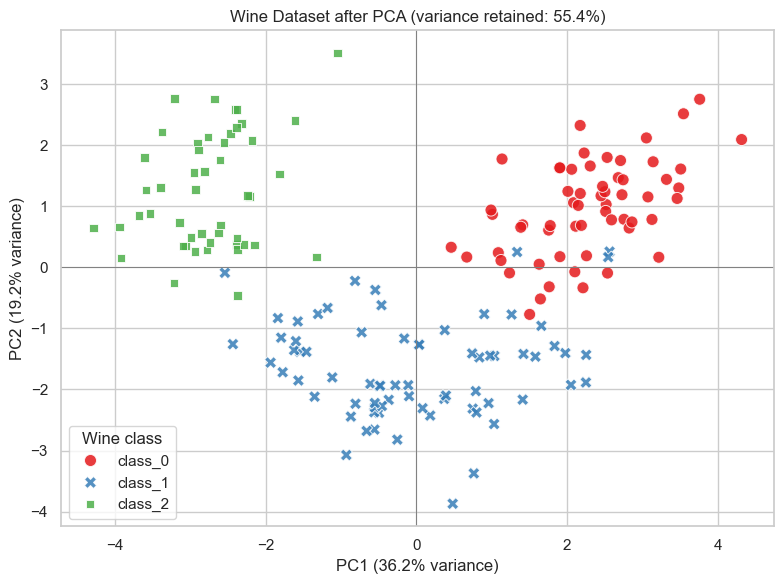

In [9]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='Class', style='Class',
                palette='Set1', s=75, alpha=0.85)
plt.axhline(0, color='grey', linewidth=0.7)
plt.axvline(0, color='grey', linewidth=0.7)
plt.title(f'Wine Dataset after PCA (variance retained: {pca_2.explained_variance_ratio_.sum():.1%})')
plt.xlabel(f'PC1 ({pca_2.explained_variance_ratio_[0]:.1%} variance)')
plt.ylabel(f'PC2 ({pca_2.explained_variance_ratio_[1]:.1%} variance)')
plt.legend(title='Wine class')
plt.tight_layout()
plt.show()

### Components required to retain at least 95% variance

PCA is fitted with all 13 components. The smallest component count whose cumulative explained variance reaches 0.95 is then selected.

,Principal Component,Explained Variance Ratio,Cumulative Explained Variance
0,1,0.3620,0.3620
1,2,0.1921,0.5541
2,3,0.1112,0.6653
3,4,0.0707,0.7360
4,5,0.0656,0.8016
5,6,0.0494,0.8510
6,7,0.0424,0.8934
7,8,0.0268,0.9202
8,9,0.0222,0.9424
9,10,0.0193,0.9617


Minimum components required for at least 95% variance: 10
Variance retained by 10 components: 96.17%


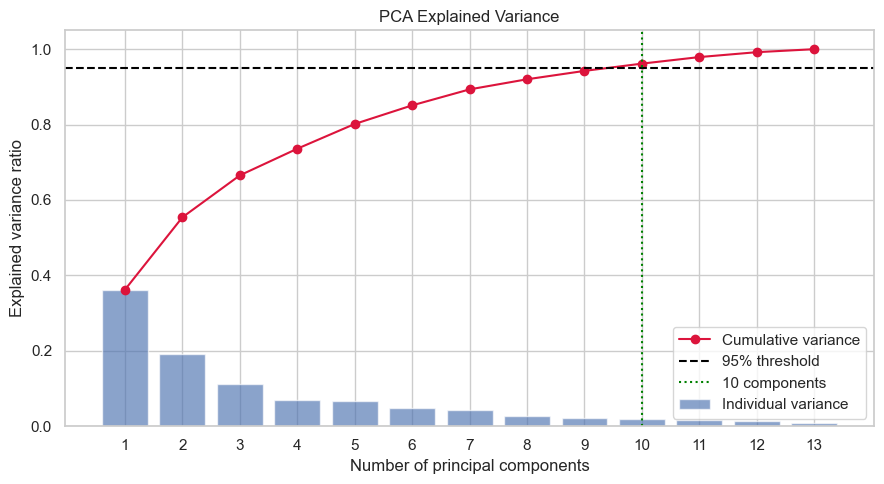

In [10]:
pca_full = PCA()
pca_full.fit(X_wine_scaled)
explained = pca_full.explained_variance_ratio_
cumulative = np.cumsum(explained)
n_95 = int(np.argmax(cumulative >= 0.95) + 1)

variance_table = pd.DataFrame({
    'Principal Component': np.arange(1, len(explained) + 1),
    'Explained Variance Ratio': explained,
    'Cumulative Explained Variance': cumulative
})
display(variance_table.round({
    'Explained Variance Ratio': 4, 'Cumulative Explained Variance': 4
}))
print(f'Minimum components required for at least 95% variance: {n_95}')
print(f'Variance retained by {n_95} components: {cumulative[n_95 - 1]:.2%}')

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(1, len(explained) + 1)
ax.bar(x, explained, alpha=0.65, label='Individual variance')
ax.plot(x, cumulative, marker='o', color='crimson', label='Cumulative variance')
ax.axhline(0.95, color='black', linestyle='--', label='95% threshold')
ax.axvline(n_95, color='green', linestyle=':', label=f'{n_95} components')
ax.set(xticks=x, xlabel='Number of principal components', ylabel='Explained variance ratio',
       title='PCA Explained Variance')
ax.legend()
plt.tight_layout()
plt.show()

### Significance of PC1 and PC2


In [11]:
loadings = pd.DataFrame(
    pca_2.components_.T, index=X_wine.columns, columns=['PC1', 'PC2']
)
display(loadings.round(3))

for pc in ['PC1', 'PC2']:
    important = loadings[pc].abs().nlargest(5).index
    terms = ', '.join(f'{feature} ({loadings.loc[feature, pc]:+.3f})' for feature in important)
    print(f'Top absolute loadings for {pc}: {terms}')

,PC1,PC2
alcohol,0.144,0.484
malic_acid,-0.245,0.225
ash,-0.002,0.316
alcalinity_of_ash,-0.239,-0.011
magnesium,0.142,0.300
total_phenols,0.395,0.065
flavanoids,0.423,-0.003
nonflavanoid_phenols,-0.299,0.029
proanthocyanins,0.313,0.039
color_intensity,-0.089,0.530


Top absolute loadings for PC1: flavanoids (+0.423), total_phenols (+0.395), od280/od315_of_diluted_wines (+0.376), proanthocyanins (+0.313), nonflavanoid_phenols (-0.299)
Top absolute loadings for PC2: color_intensity (+0.530), alcohol (+0.484), proline (+0.365), ash (+0.316), magnesium (+0.300)




PC1 explains the largest possible variance and is strongly associated with a broad combination of phenolic and color-related measurements. PC2 captures the largest remaining, orthogonal variation, with strong contributions from another combination including ash-related and alcohol-related measurements. The loading table above provides the exact data-driven interpretation. Although two components lose substantial variance, they reveal visible class structure in a plane. Retaining at least 95% variance requires the larger component count calculated above.

### Advantages, limitations, and applications of PCA

**Advantages**
- Makes data simpler by reducing the number of features.
- Keeps most of the important information (variance) from the original data.
- Makes it easy to plot and visualize high-dimensional data in 2D or 3D.
- Removes noise and redundant features.

**Limitations**
- New components are combinations of features, so they are hard to interpret.
- Sensitive to scaling, so data must be standardized first.
- Sensitive to outliers.
- Only captures linear relationships, not complex/non-linear patterns.
- Does not use class labels, so it may not separate categories well.

**Applications**
- Data visualization
- Image compression
- Noise reduction
- Feature extraction before machine learning
- Preprocessing large datasets like genomic, financial, and sensor data

## Extra Credit: Linear Discriminant Analysis (LDA)

LDA explained discriminative variance ratio: [0.6875 0.3125]
Total discriminative information represented: 100.00%


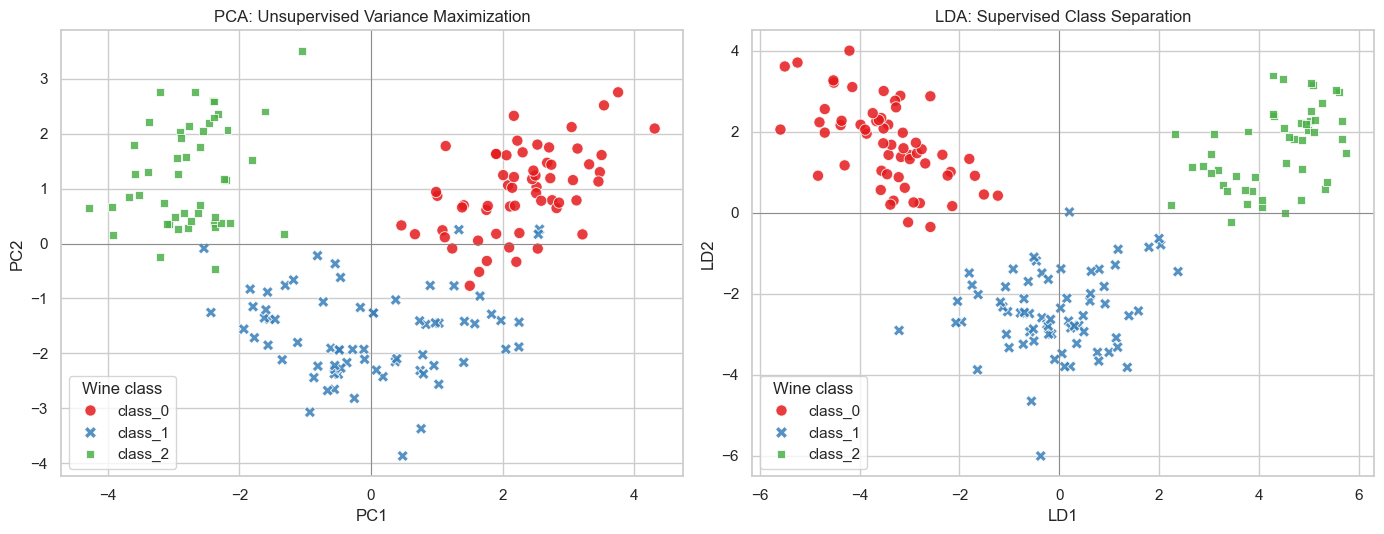

In [12]:
lda = LinearDiscriminantAnalysis(n_components=2)
X_lda = lda.fit_transform(X_wine_scaled, y_wine)

lda_df = pd.DataFrame(X_lda, columns=['LD1', 'LD2'])
lda_df['Class'] = y_wine.map(dict(enumerate(wine.target_names)))

print('LDA explained discriminative variance ratio:', np.round(lda.explained_variance_ratio_, 4))
print(f'Total discriminative information represented: {lda.explained_variance_ratio_.sum():.2%}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='Class', style='Class',
                palette='Set1', s=65, alpha=0.85, ax=axes[0])
axes[0].set_title('PCA: Unsupervised Variance Maximization')
sns.scatterplot(data=lda_df, x='LD1', y='LD2', hue='Class', style='Class',
                palette='Set1', s=65, alpha=0.85, ax=axes[1])
axes[1].set_title('LDA: Supervised Class Separation')
for ax in axes:
    ax.axhline(0, color='grey', linewidth=0.6)
    ax.axvline(0, color='grey', linewidth=0.6)
    ax.legend(title='Wine class')
plt.tight_layout()
plt.show()

### PCA versus LDA observations

| Criterion | PCA | LDA |
|---|---|---|
| Learning type | Unsupervised | Supervised |
| Uses class labels | No | Yes |
| Objective | Maximize total variance | Maximize class separability |
| Maximum dimensions | Up to number of original features | At most classes minus one |
| Two-dimensional wine plot | Shows natural structure with some overlap | Produces clearer class separation |
| Best suited for | Compression, visualization, noise reduction | Label-aware feature extraction and classification |